# PTM enzyme–substrate paths

Uses **`enzyme_*`** columns in `ptm.txt` (human phospho). Relates literature **writer → substrate** edges to **per-condition top gene lists** and optionally **`ksea_prerank_long.tsv`**.

**Inputs:** `data/ptm.txt`, `data.tsv`, optional `output/analyze/ksea_prerank_long.tsv`.

In [6]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402
import ptm_data as ptm  # noqa: E402

DATA_PATH = ROOT / "data.tsv"
PTM_PATH = ROOT / "data" / "ptm.txt"
PPIC_PATH = ROOT / "data" / "ppic" / "edges.tsv"
KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"

THR = float(-np.log10(0.05))
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 40)

print("ROOT =", ROOT)


ROOT = /Users/ph/Documents/phospho_mhg_anno


In [7]:
TOP_N = 150
df_ptm = ptm.load_ptm(PTM_PATH)
df_phos = ptm.add_site_key_ptm(ptm.filter_human(ptm.filter_ptm_type(df_ptm, 'PHOSPHORYLATION')))
df_e = df_phos.copy()
df_e['enzyme_genename'] = df_e['enzyme_genename'].astype(str).str.strip()
df_e = df_e[df_e['enzyme_genename'].str.len() > 0]
df_e['_edge'] = df_e['enzyme_genename'].str.upper() + ' -> ' + df_e['substrate_genename'].astype(str).str.upper()
print('Rows with enzyme (human phospho):', len(df_e))
DATA = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)


Rows with enzyme (human phospho): 18434


/Users/ph/.pyenv/versions/3.12.7/lib/python3.12/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


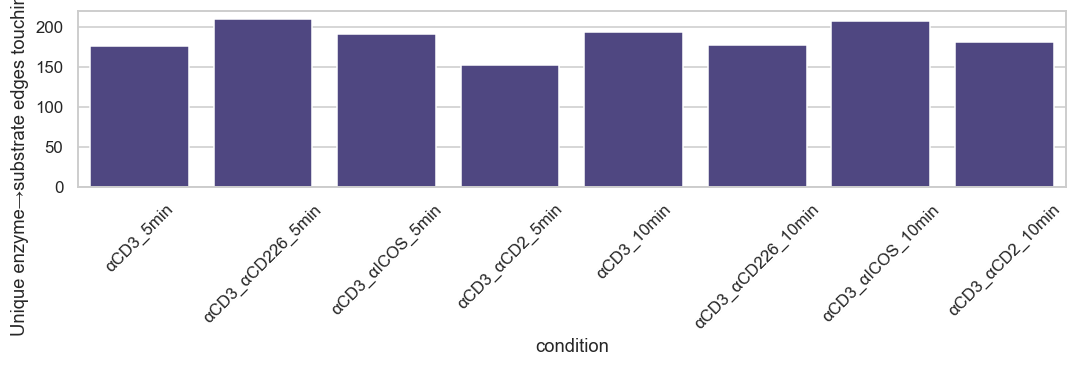

In [8]:
def top_genes_for_condition(df: pd.DataFrame, cond, n: int) -> set[str]:
    log2 = pd.to_numeric(df[cond.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(df[cond.neglogp_col], errors='coerce')
    sc = (log2 * nlp).abs()
    tmp = df.assign(_s=sc).dropna(subset=['_s'])
    tmp = tmp.sort_values('_s', ascending=False)
    return set(tmp['geneid'].astype(str).str.upper().head(n))
touch = []
for c in CONDITIONS:
    gset = top_genes_for_condition(DATA, c, TOP_N)
    sub = df_e[df_e['substrate_genename'].astype(str).str.upper().isin(gset)]
    touch.append({'condition': c.condition_id, 'n_edges': sub['_edge'].nunique()})
bar_df = pd.DataFrame(touch)
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.barplot(data=bar_df, x='condition', y='n_edges', ax=ax, color='darkslateblue')
ax.set_ylabel(f'Unique enzyme→substrate edges touching top {TOP_N} genes')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


## Heatmap: kinases (enzymes) × condition — substrate hits in top-N gene set

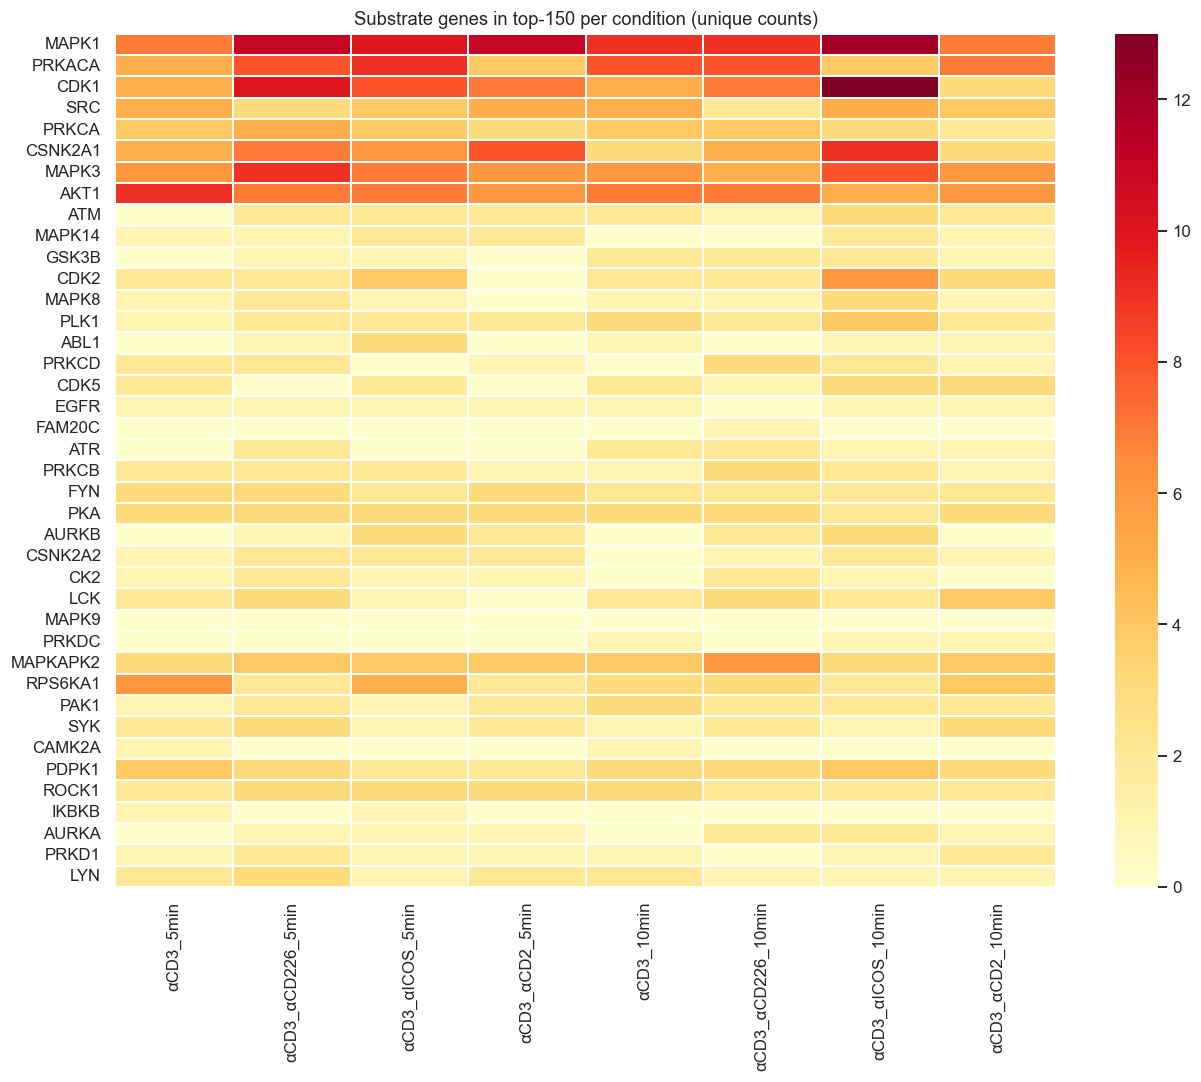

In [9]:
KINASE_CAP = 40
enzyme_counts = df_e['enzyme_genename'].str.upper().value_counts()
top_kin = enzyme_counts.head(KINASE_CAP).index.tolist()
mat = []
for kin in top_kin:
    row = []
    for c in CONDITIONS:
        gset = top_genes_for_condition(DATA, c, TOP_N)
        sub = df_e[(df_e['enzyme_genename'].str.upper() == kin) & (df_e['substrate_genename'].astype(str).str.upper().isin(gset))]
        row.append(sub['substrate_genename'].nunique())
    mat.append(row)
hm = pd.DataFrame(mat, index=top_kin, columns=[c.condition_id for c in CONDITIONS])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(hm, ax=ax, cmap='YlOrRd', linewidths=0.2)
ax.set_title(f'Substrate genes in top-{TOP_N} per condition (unique counts)')
fig.tight_layout()
plt.show()


## Optional: overlap with KSEA prerank

Kinases are taken as **max |NES| across conditions** from `ksea_prerank_long.tsv`, then those with **max |NES| ≥ 1.35** (this dataset’s |NES| stays well **below 2**). If fewer than eight pass, we fall back to the **top 25** kinases by that max |NES|. Overlap uses **exact uppercase gene symbols** between KSEA `kinase` and `ptm.txt` `enzyme_genename` (aliases like ERK2 vs MAPK1 are not merged).

In [10]:
if not KSEA_LONG.is_file():
    print('No ksea_prerank_long.tsv — run analyze/kinase_substrate_prerank.py')
else:
    klong = pd.read_csv(KSEA_LONG, sep='\t')
    if 'NES' not in klong.columns or 'kinase' not in klong.columns:
        print('Unexpected ksea columns:', klong.columns.tolist())
    else:
        klong['kinase_u'] = klong['kinase'].astype(str).str.strip().str.upper()
        nes = pd.to_numeric(klong['NES'], errors='coerce')
        mx = klong.assign(_abs=nes.abs()).groupby('kinase_u', sort=False)['_abs'].max()
        print('KSEA kinases:', mx.shape[0], '| max |NES| in this file:', float(mx.max()) if len(mx) else float('nan'))
        NES_MIN = 1.35
        hi = set(mx[mx >= NES_MIN].index.astype(str))
        if len(hi) < 8:
            hi = set(mx.nlargest(25).index.astype(str))
            print('Using top-25 kinases by max |NES| (threshold hit fewer than 8 kinases).')
        else:
            print(f"Using kinases with max |NES| >= {NES_MIN} (n={len(hi)}).")
        ptm_enz = set(df_e['enzyme_genename'].astype(str).str.strip().str.upper())
        ptm_enz.discard('')
        both = sorted(hi & ptm_enz)
        only_ksea = sorted(hi - ptm_enz)
        print('KSEA-selected kinases also listed as PTM enzymes:', len(both))
        print(both[:40], '...' if len(both) > 40 else '')
        print('KSEA-selected but not in ptm enzyme_genename (alias / missing / gap):', len(only_ksea))
        print(only_ksea[:40], '...' if len(only_ksea) > 40 else '')


KSEA kinases: 78 | max |NES| in this file: 1.8153457281045315
Using kinases with max |NES| >= 1.35 (n=23).
KSEA-selected kinases also listed as PTM enzymes: 13
['CAMK2A', 'CDC7', 'CDK9', 'EGFR', 'FYN', 'GSK3A', 'HIPK2', 'MAPKAPK2', 'PDK1', 'RET', 'ROCK1', 'SYK', 'ULK1'] 
KSEA-selected but not in ptm enzyme_genename (alias / missing / gap): 10
['AMPKA2', 'CHK2', 'CK1A', 'ERK1', 'ERK2', 'JNK2', 'P90RSK', 'PKACA', 'PKCA', 'PKCB'] 
